In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/machine-learning-comp-432-project/sample_submission.csv
/kaggle/input/machine-learning-comp-432-project/train.csv
/kaggle/input/machine-learning-comp-432-project/test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data

train_path = "/kaggle/input/machine-learning-comp-432-project/train.csv"
test_path  = "/kaggle/input/machine-learning-comp-432-project/test.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

# Feature columns
feature_cols = [c for c in train_df.columns if c.startswith("feature")]

X_train_full = train_df[feature_cols].values.astype(np.float32)
print("X_train_full shape:", X_train_full.shape)  # (n_samples, 500)


Train: (115406, 502)
Test : (49460, 501)
X_train_full shape: (115406, 500)


In [3]:
# 2. Standardize features (fit on TRAIN ONLY)

# Compute mean and std over training data
pca_mean = X_train_full.mean(axis=0, keepdims=True)      # shape (1, 500)
pca_std  = X_train_full.std(axis=0, keepdims=True) + 1e-8

X_train_std = (X_train_full - pca_mean) / pca_std

print("Standardized train shape:", X_train_std.shape)

Standardized train shape: (115406, 500)


In [4]:
# 3. Covariance matrix and eigen-decomposition

# Covariance of columns (features); rowvar=False means each column is a variable
cov_matrix = np.cov(X_train_std, rowvar=False)   # shape (500, 500)
print("Cov matrix shape:", cov_matrix.shape)

# Since covariance matrix is symmetric, use eigh (for Hermitian matrices)
eigvals, eigvecs = np.linalg.eigh(cov_matrix)

# Sort eigenvalues (and eigenvectors) in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]   # columns are principal directions

Cov matrix shape: (500, 500)


In [6]:
# 4. Explained variance and cumulative explained variance

total_var = eigvals.sum()
explained_variance_ratio = eigvals / total_var  # shape (500,)

cumulative_explained = np.cumsum(explained_variance_ratio)

# Find number of components to reach at least 95% variance
target_variance = 0.95
k_95 = np.searchsorted(cumulative_explained, target_variance) + 1
print(f"\nNumber of principal components to explain {target_variance*100:.1f}% variance: {k_95}")

# Show first few PCs
print("\nTop components summary:")
for i in range(10):
    print(
        f"PC{i+1:2d}: "
        f"individual = {explained_variance_ratio[i]*100:6.2f}% | "
        f"cumulative = {cumulative_explained[i]*100:6.2f}%"
    )



Number of principal components to explain 95.0% variance: 451

Top components summary:
PC 1: individual =   3.84% | cumulative =   3.84%
PC 2: individual =   2.61% | cumulative =   6.45%
PC 3: individual =   1.73% | cumulative =   8.18%
PC 4: individual =   0.92% | cumulative =   9.10%
PC 5: individual =   0.83% | cumulative =   9.93%
PC 6: individual =   0.74% | cumulative =  10.67%
PC 7: individual =   0.66% | cumulative =  11.33%
PC 8: individual =   0.63% | cumulative =  11.96%
PC 9: individual =   0.54% | cumulative =  12.50%
PC10: individual =   0.50% | cumulative =  13.00%


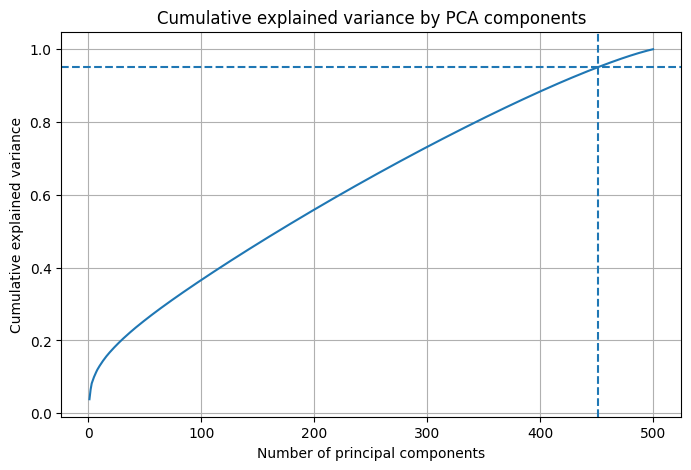

In [7]:
# 5. Plot cumulative explained variance (EDA visualization)

plt.figure(figsize=(8, 5))
plt.plot(
    np.arange(1, len(cumulative_explained) + 1),
    cumulative_explained
)
plt.axhline(target_variance, linestyle="--")
plt.axvline(k_95, linestyle="--")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance by PCA components")
plt.grid(True)
plt.show()
